In [1]:
# Step 1: Import the required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Dataset Selection

For this project, I selected the Heart Disease dataset. This dataset is suitable for a classification problem because the goal is to predict whether a patient has heart disease or not based on medical information.

In [5]:
# Load the uploaded dataset

df = pd.read_csv("heart.csv")

# Display the first five rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data Exploration and Preprocessing

Before training the machine learning models, it is important to understand the structure and quality of the dataset. This step includes examining the dataset, checking for missing values and duplicate records, and preparing the data for model training.

In [6]:
# Display basic information about the dataset

print("Shape of the dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Shape of the dataset: (303, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# Summary statistics

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# Check for missing values

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
# Check for duplicate records

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [10]:
# Remove duplicate rows if any exist

df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (302, 14)


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the characteristics of the dataset before building machine learning models. In this section, visualizations are used to examine the distribution of the target variable, relationships between features, and correlations among variables.

In [11]:
# Display the first five rows

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


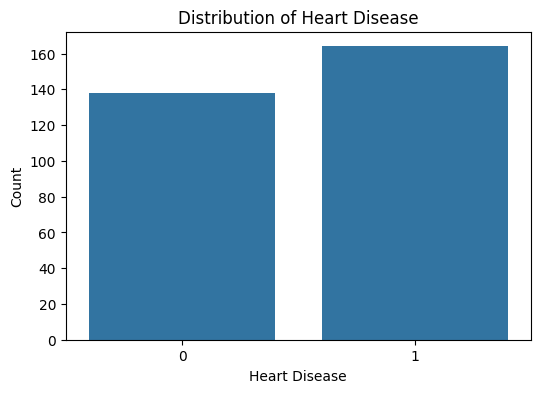

In [12]:
# Distribution of the target variable

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Distribution of Heart Disease")

plt.xlabel("Heart Disease")

plt.ylabel("Count")

plt.show()

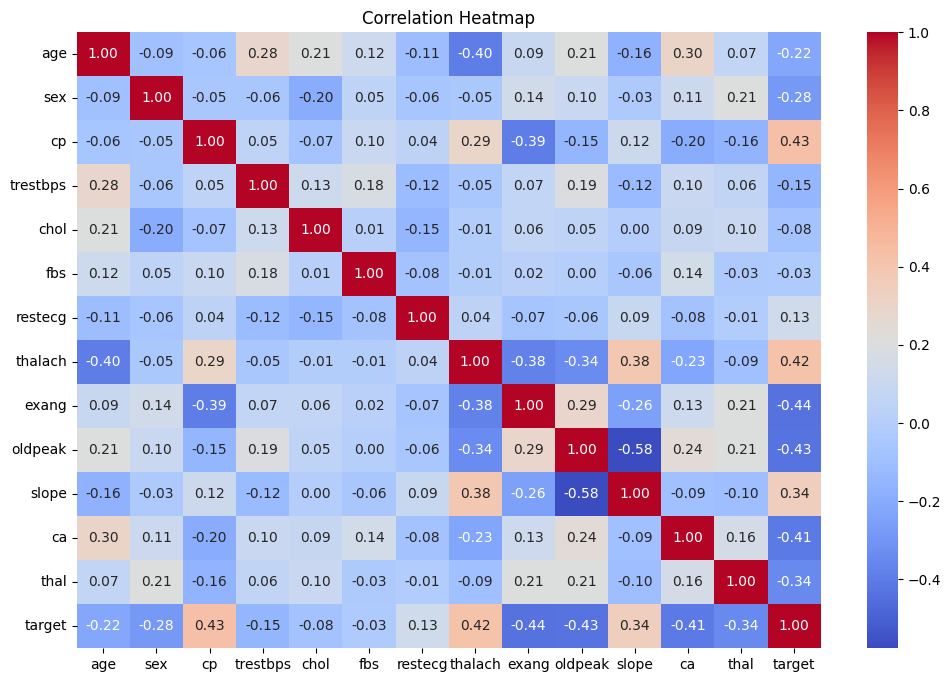

In [13]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

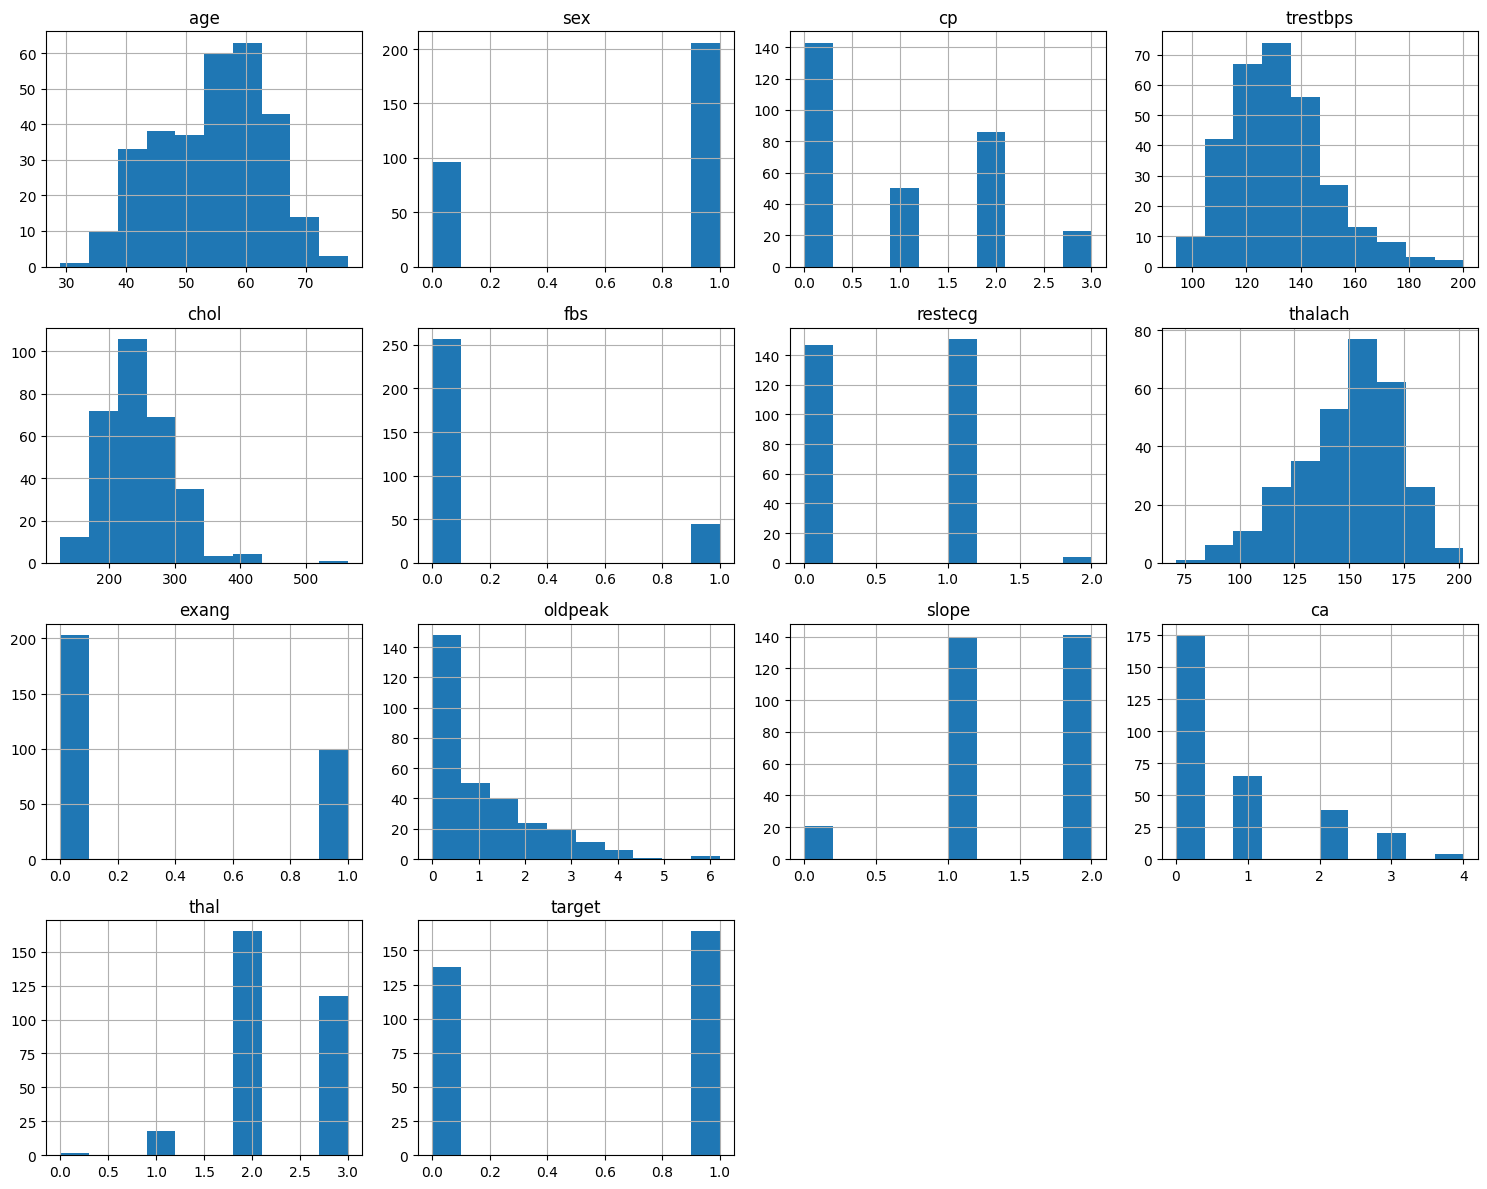

In [14]:
# Histograms of all numerical variables

df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

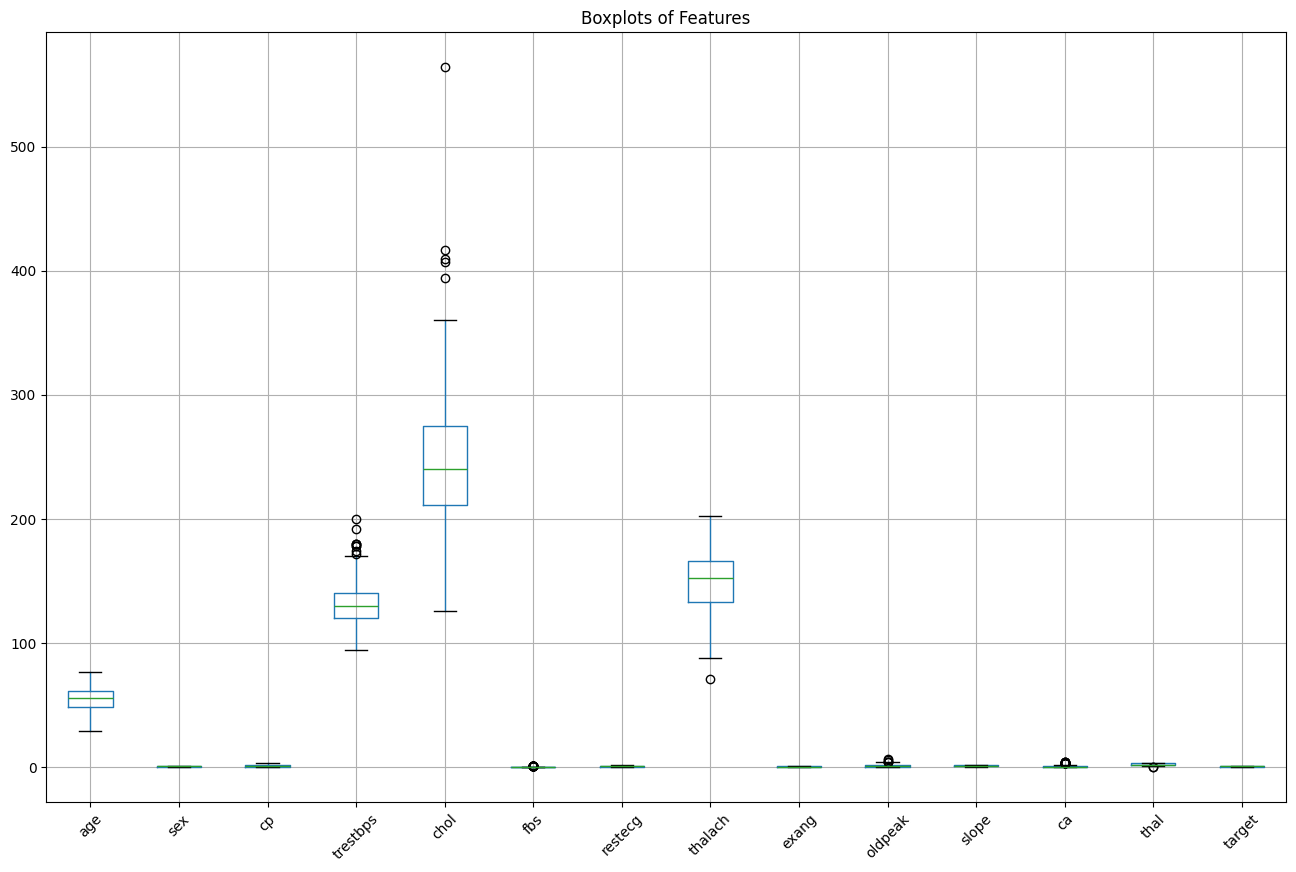

In [15]:
# Boxplots to detect outliers

plt.figure(figsize=(16,10))

df.boxplot(rot=45)

plt.title("Boxplots of Features")

plt.show()

### EDA Findings

The exploratory data analysis shows that the dataset contains both patients with and without heart disease. The correlation heatmap indicates that some features have stronger relationships with the target variable than others. The histograms reveal the distribution of each feature, while the boxplots help identify potential outliers. Overall, the dataset appears suitable for training classification models after basic preprocessing.

## Feature Engineering

Before training the machine learning models, the dataset is divided into input features (X) and the target variable (y). The data is then split into training and testing sets. Feature scaling is applied using StandardScaler to improve the performance of machine learning algorithms such as Logistic Regression.

In [16]:
# Separate features and target variable

X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (302, 13)
Target shape: (302,)


In [17]:
# Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (241, 13)
Testing set: (61, 13)


In [18]:
# Standardize the feature values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## Model 1: Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. It predicts the probability that an observation belongs to a particular class.

In [19]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [20]:
# Predict on the test set

y_pred_log = log_model.predict(X_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression Performance")

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

Logistic Regression Performance
Accuracy : 0.819672131147541
Precision: 0.8387096774193549
Recall   : 0.8125
F1 Score : 0.8253968253968254


## Model 2: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is widely used for classification tasks because of its strong performance and ability to handle complex datasets.

In [22]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
# Predict on the test set

y_pred_rf = rf_model.predict(X_test)

In [24]:
print("Random Forest Performance")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Performance
Accuracy : 0.8688524590163934
Precision: 0.9
Recall   : 0.84375
F1 Score : 0.8709677419354839


In [25]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.819672,0.83871,0.81250,0.825397
1,Random Forest,0.868852,0.90000,0.84375,0.870968


## Model Evaluation

The models are evaluated using confusion matrices, classification reports, and ROC curves. These evaluation techniques help measure the performance of each classifier and identify the best-performing model.

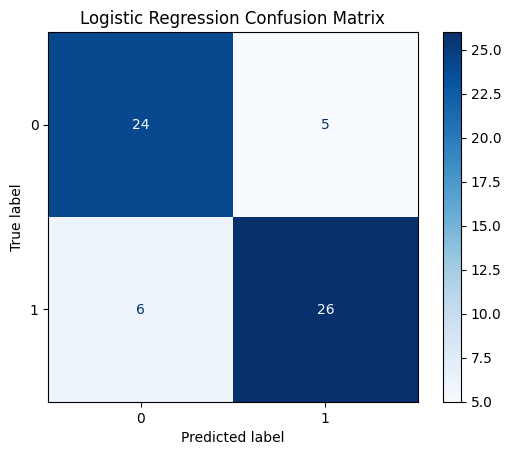

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

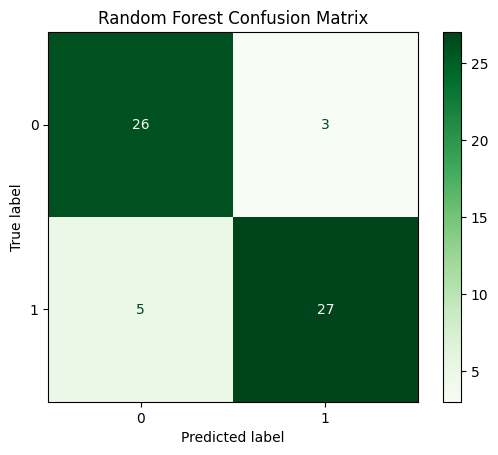

In [27]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

print("\n" + "="*60 + "\n")

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



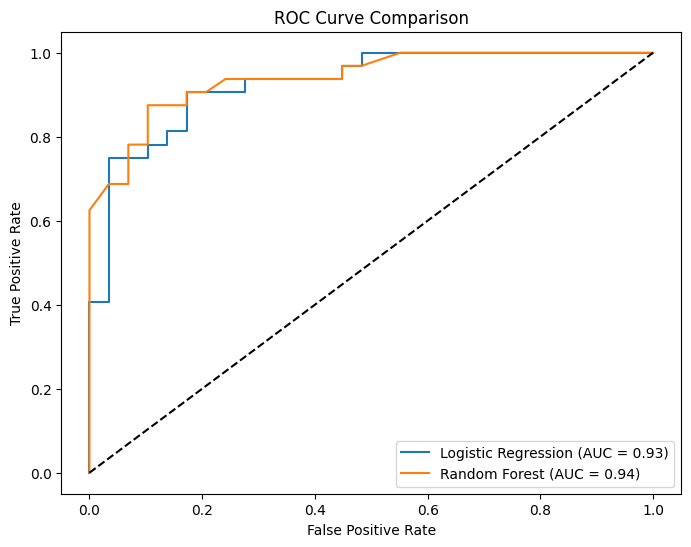

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression probabilities
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f"Logistic Regression (AUC = {roc_auc_score(y_test, log_probs):.2f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

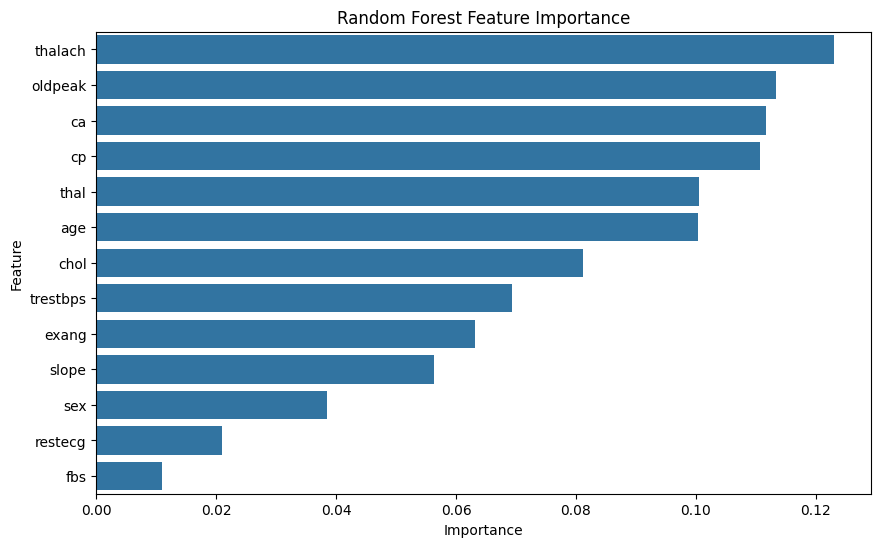

,Feature,Importance
7,thalach,0.123093
9,oldpeak,0.113440
11,ca,0.111613
2,cp,0.110655
12,thal,0.100442
0,age,0.100309
4,chol,0.081189
3,trestbps,0.069357
8,exang,0.063221
10,slope,0.056294


In [30]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

importance

## Model Interpretation

The Random Forest classifier achieved the best overall performance, with an accuracy of approximately 86.9%, outperforming the Logistic Regression model. It also produced higher precision, recall, and F1-score, indicating a better balance between correctly identifying patients with heart disease and minimizing false predictions.

The confusion matrices show that Random Forest classified more observations correctly than Logistic Regression. The ROC curve further demonstrates strong discriminative performance, with the Random Forest model achieving the highest Area Under the Curve (AUC).

The feature importance analysis indicates that variables such as chest pain type (`cp`), maximum heart rate achieved (`thalach`), ST depression (`oldpeak`), and the number of major vessels (`ca`) are among the most influential predictors of heart disease in this dataset.

## Deployment Strategy

The Random Forest model is recommended for deployment because it achieved the highest performance across all evaluation metrics. The trained model can be saved using the `joblib` or `pickle` library and integrated into a web application using Flask or FastAPI. Users can enter patient information through a web interface, and the model can return a prediction indicating the likelihood of heart disease. The application can be hosted on cloud platforms such as Heroku, Render, or Microsoft Azure, making it accessible to healthcare professionals.

## Model Monitoring

Once deployed, the model should be monitored regularly to ensure that it continues to perform accurately. New patient data should be compared with historical data to detect data drift or changes in feature distributions. Model performance should be evaluated periodically using metrics such as accuracy, precision, recall, and F1-score. If performance decreases over time, the model should be retrained using more recent data. Regular maintenance, logging, and monitoring will help maintain the reliability and effectiveness of the prediction system.

## Conclusion

This project demonstrated the complete machine learning workflow for predicting heart disease using the Heart Disease dataset. The data was cleaned, explored, and prepared before training two classification models: Logistic Regression and Random Forest. Both models performed well, but the Random Forest classifier achieved the highest accuracy, precision, recall, F1-score, and ROC-AUC, making it the best-performing model for this dataset. The project also discussed deployment and monitoring strategies, highlighting the importance of maintaining model performance in real-world applications.